In [281]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve,recall_score, precision_score,f1_score

In [282]:
mlflow.autolog()

2026/05/18 10:51:23 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


In [283]:
ckd_data = pd.read_csv('./CKD_Dataset/ckd.csv')
ckd_data.head()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Blood Glucose Random,...,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
0,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,...,32,6700,3.9,yes,no,no,poor,yes,yes,1
1,53,90,1.020,2,0,abnormal,abnormal,present,notpresent,70,...,29,12100,3.7,yes,yes,no,poor,no,yes,1
2,63,70,1.010,3,0,abnormal,abnormal,present,notpresent,380,...,32,4500,3.8,yes,yes,no,poor,yes,no,1
3,68,80,1.010,3,2,normal,abnormal,present,present,157,...,16,11000,2.6,yes,yes,yes,poor,yes,no,1
4,61,80,1.015,2,0,abnormal,abnormal,notpresent,notpresent,173,...,24,9200,3.2,yes,yes,yes,poor,yes,yes,1


In [284]:
ckd_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      158 non-null    int64  
 1   Blood Pressure           158 non-null    int64  
 2   Specific Gravity         158 non-null    float64
 3   Albumin                  158 non-null    int64  
 4   Sugar                    158 non-null    int64  
 5   Red Blood Cells          158 non-null    object 
 6   Pus Cell                 158 non-null    object 
 7   Pus Cell clumps          158 non-null    object 
 8   Bacteria                 158 non-null    object 
 9   Blood Glucose Random     158 non-null    int64  
 10  Blood Urea               158 non-null    int64  
 11  Serum Creatinine         158 non-null    float64
 12  Sodium                   158 non-null    int64  
 13  Potassium                158 non-null    float64
 14  Hemoglobin               1

In [285]:
ckd_data.describe()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Blood Glucose Random,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Class
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,49.563291,74.050633,1.019873,0.797468,0.253165,131.341772,52.575949,2.188608,138.848101,4.636709,13.687342,41.917722,8475.949367,4.891772,0.272152
std,15.512244,11.175381,0.005499,1.413130,0.813397,64.939832,47.395382,3.077615,7.489421,3.476351,2.882204,9.105164,3126.880181,1.019364,0.446483
min,6.000000,50.000000,1.005000,0.000000,0.000000,70.000000,10.000000,0.400000,111.000000,2.500000,3.100000,9.000000,3800.000000,2.100000,0.000000
25%,39.250000,60.000000,1.020000,0.000000,0.000000,97.000000,26.000000,0.700000,135.000000,3.700000,12.600000,37.500000,6525.000000,4.500000,0.000000
50%,50.500000,80.000000,1.020000,0.000000,0.000000,115.500000,39.500000,1.100000,139.000000,4.500000,14.250000,44.000000,7800.000000,4.950000,0.000000
75%,60.000000,80.000000,1.025000,1.000000,0.000000,131.750000,49.750000,1.600000,144.000000,4.900000,15.775000,48.000000,9775.000000,5.600000,1.000000
max,83.000000,110.000000,1.025000,4.000000,5.000000,490.000000,309.000000,15.200000,150.000000,47.000000,17.800000,54.000000,26400.000000,8.000000,1.000000


In [286]:
ckd_data.isnull().sum()

Age                        0
Blood Pressure             0
Specific Gravity           0
Albumin                    0
Sugar                      0
Red Blood Cells            0
Pus Cell                   0
Pus Cell clumps            0
Bacteria                   0
Blood Glucose Random       0
Blood Urea                 0
Serum Creatinine           0
Sodium                     0
Potassium                  0
Hemoglobin                 0
Packed Cell Volume         0
White Blood Cell Count     0
Red Blood Cell Count       0
Hypertension               0
Diabetes Mellitus          0
Coronary Artery Disease    0
Appetite                   0
Pedal Edema                0
Anemia                     0
Class                      0
dtype: int64

In [287]:
duplicated_data = ckd_data.duplicated().sum()
print(f'The number of duplicated rows in the dataset is: {duplicated_data}')

The number of duplicated rows in the dataset is: 0


In [288]:
ckd_data = ckd_data.rename(columns={'Blood Glucose Random': 'Blood Glucose'})
ckd_data['Blood Glucose'].head()

0    117
1     70
2    380
3    157
4    173
Name: Blood Glucose, dtype: int64

In [289]:
categorical_data = ckd_data.select_dtypes(include=['object'])
categorical_data.head()

,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia
0,normal,abnormal,present,notpresent,yes,no,no,poor,yes,yes
1,abnormal,abnormal,present,notpresent,yes,yes,no,poor,no,yes
2,abnormal,abnormal,present,notpresent,yes,yes,no,poor,yes,no
3,normal,abnormal,present,present,yes,yes,yes,poor,yes,no
4,abnormal,abnormal,notpresent,notpresent,yes,yes,yes,poor,yes,yes


In [290]:
def encode_categorical_data(categorical_data,unique_values):
    if len(unique_values) == 2:
        mapping = {unique_values[0]: 0, unique_values[1]: 1}
        categorical_data[column] = categorical_data[column].map(mapping)
    else:
        categorical_data = pd.get_dummies(categorical_data, columns=[column], drop_first=True)
    return categorical_data
    #categorical_data.head()


In [291]:
for column in categorical_data:
    unique_values = categorical_data[column].unique()
    print(f'Column: {column}, Unique Values: {unique_values}')
    categorical_data_encoded = encode_categorical_data(categorical_data, unique_values)

Column: Red Blood Cells, Unique Values: ['normal' 'abnormal']
Column: Pus Cell, Unique Values: ['abnormal' 'normal']
Column: Pus Cell clumps, Unique Values: ['present' 'notpresent']
Column: Bacteria, Unique Values: ['notpresent' 'present']
Column: Hypertension, Unique Values: ['yes' 'no']
Column: Diabetes Mellitus, Unique Values: ['no' 'yes']
Column: Coronary Artery Disease, Unique Values: ['no' 'yes']
Column: Appetite, Unique Values: ['poor' 'good']
Column: Pedal Edema, Unique Values: ['yes' 'no']
Column: Anemia, Unique Values: ['yes' 'no']


In [292]:
categorical_data_encoded.head()

,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia
0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,1,0,0,1,0
2,1,0,0,0,0,1,0,0,0,1
3,0,0,0,1,0,1,1,0,0,1
4,1,0,1,0,0,1,1,0,0,0


In [293]:
ckd_data[categorical_data_encoded.columns] = categorical_data_encoded
ckd_data.head()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Blood Glucose,...,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia,Class
0,48,70,1.005,4,0,0,0,0,0,117,...,32,6700,3.9,0,0,0,0,0,0,1
1,53,90,1.020,2,0,1,0,0,0,70,...,29,12100,3.7,0,1,0,0,1,0,1
2,63,70,1.010,3,0,1,0,0,0,380,...,32,4500,3.8,0,1,0,0,0,1,1
3,68,80,1.010,3,2,0,0,0,1,157,...,16,11000,2.6,0,1,1,0,0,1,1
4,61,80,1.015,2,0,1,0,1,0,173,...,24,9200,3.2,0,1,1,0,0,0,1


# Data Visualizations
* we will look at simple feature relationships:
1. Hemoglobin and Blood Pressue based on CKD Class
2. Blood Glucose and Blood Urea based on CKD Class
3. Hemoglobin and Blood Glucose based on CKD Class
4. Age distribution based on CKD Class
5. Coronary Artery Disease and Age
6. Class distribution for CKD class observation

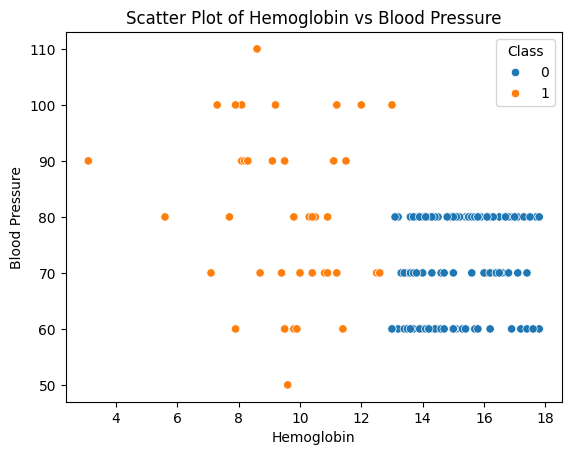

In [294]:
sns.scatterplot(x='Hemoglobin', y='Blood Pressure', hue='Class', data=ckd_data)
plt.title('Scatter Plot of Hemoglobin vs Blood Pressure')
plt.xlabel('Hemoglobin')
plt.ylabel('Blood Pressure')
plt.legend(title='Class')
plt.show()

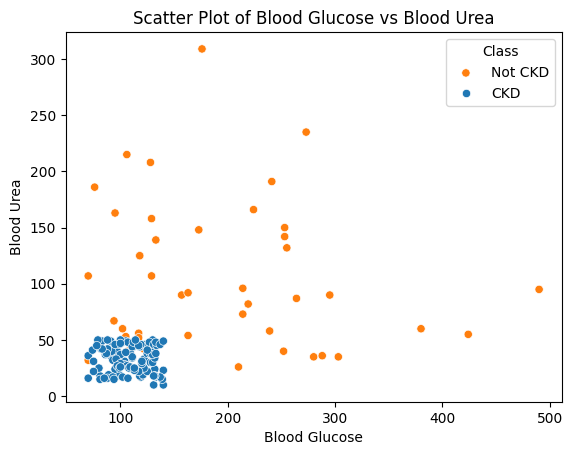

In [295]:
sns.scatterplot(x='Blood Glucose', y='Blood Urea', hue='Class', data=ckd_data)
plt.title('Scatter Plot of Blood Glucose vs Blood Urea')
plt.xlabel('Blood Glucose')
plt.ylabel('Blood Urea')
plt.legend(title='Class',labels=['Not CKD', 'CKD'])
plt.show()

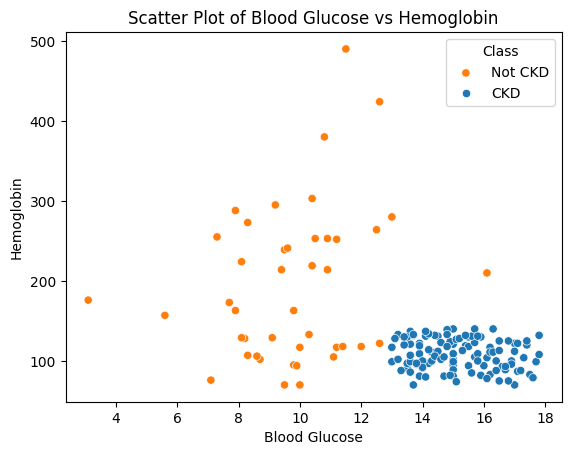

In [296]:
sns.scatterplot(x='Hemoglobin', y='Blood Glucose', hue='Class', data=ckd_data)
plt.title('Scatter Plot of Blood Glucose vs Hemoglobin')
plt.xlabel('Blood Glucose')
plt.ylabel('Hemoglobin')
plt.legend(title='Class',labels=['Not CKD', 'CKD'])
plt.show()

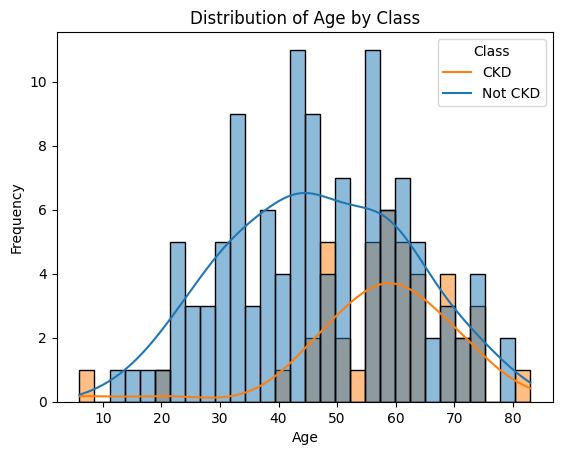

In [297]:
sns.histplot(data=ckd_data, x='Age', hue='Class', kde=True, bins=30)
plt.title('Distribution of Age by Class')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(title='Class', labels=['CKD', 'Not CKD'])
plt.show()

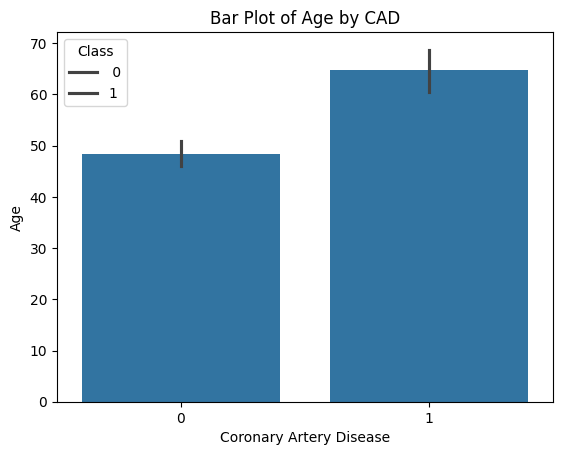

In [298]:
sns.barplot(x='Coronary Artery Disease', y='Age', data=ckd_data)
plt.title('Bar Plot of Age by CAD')
plt.xlabel('Coronary Artery Disease')
plt.ylabel('Age')
plt.legend(title='Class', labels=[' 0', '1'])
plt.show()

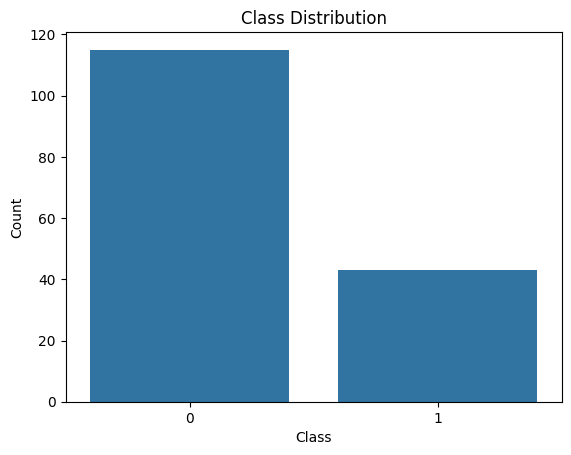

In [299]:
ckd_count = ckd_data['Class'].value_counts()
sns.barplot(x=ckd_count.index, y=ckd_count.values, errorbar=None)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

* We will observe compound detection levels within a few set of samples

In [300]:
ckd_data['Coronary Artery Disease'].value_counts(normalize=True)

Coronary Artery Disease
0    0.93038
1    0.06962
Name: proportion, dtype: float64

In [301]:
categorical_data_encoded.head()

,Red Blood Cells,Pus Cell,Pus Cell clumps,Bacteria,Hypertension,Diabetes Mellitus,Coronary Artery Disease,Appetite,Pedal Edema,Anemia
0,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,1,0,0,1,0
2,1,0,0,0,0,1,0,0,0,1
3,0,0,0,1,0,1,1,0,0,1
4,1,0,1,0,0,1,1,0,0,0


In [302]:
ckd_data['Bacteria'].value_counts(normalize=True)

Bacteria
0    0.924051
1    0.075949
Name: proportion, dtype: float64

In [303]:
ckd_data['Diabetes Mellitus'].value_counts(normalize=True)

Diabetes Mellitus
0    0.822785
1    0.177215
Name: proportion, dtype: float64

In [304]:
ckd_data['Anemia'].value_counts(normalize=True)

Anemia
1    0.898734
0    0.101266
Name: proportion, dtype: float64

In [305]:
ckd_data['Class'].value_counts(normalize=True)

Class
0    0.727848
1    0.272152
Name: proportion, dtype: float64

In [306]:
ckd_corr = ckd_data.corr()['Class'].sort_values(ascending=False)


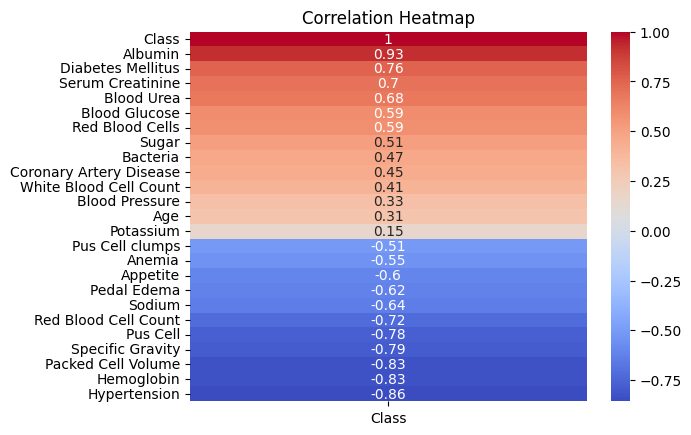

In [307]:
sns.heatmap(ckd_corr.to_frame(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [308]:
high_relationships = ckd_corr[ckd_corr.abs() > 0.75]
print(high_relationships)

Class                 1.000000
Albumin               0.925816
Diabetes Mellitus     0.758965
Pus Cell             -0.775388
Specific Gravity     -0.790102
Packed Cell Volume   -0.827983
Hemoglobin           -0.833790
Hypertension         -0.856334
Name: Class, dtype: float64


In [309]:
Scale_Analysis = ckd_data.drop(categorical_data.columns, axis=1)
Scale_Analysis.drop('Class', axis=1, inplace=True)
Scale_Analysis.head()

,Age,Blood Pressure,Specific Gravity,Albumin,Sugar,Blood Glucose,Blood Urea,Serum Creatinine,Sodium,Potassium,Hemoglobin,Packed Cell Volume,White Blood Cell Count,Red Blood Cell Count
0,48,70,1.005,4,0,117,56,3.8,111,2.5,11.2,32,6700,3.9
1,53,90,1.020,2,0,70,107,7.2,114,3.7,9.5,29,12100,3.7
2,63,70,1.010,3,0,380,60,2.7,131,4.2,10.8,32,4500,3.8
3,68,80,1.010,3,2,157,90,4.1,130,6.4,5.6,16,11000,2.6
4,61,80,1.015,2,0,173,148,3.9,135,5.2,7.7,24,9200,3.2


In [310]:
smallScale_targeted_columns = Scale_Analysis[['Age','Specific Gravity','Albumin','Sugar','Serum Creatinine','Potassium','Red Blood Cell Count']]
largeScale_targeted_columns = Scale_Analysis.loc[:, ['Blood Pressure','Blood Glucose','Blood Urea','Sodium','White Blood Cell Count']]

In [311]:
smallScale_targeted_columns.describe()

,Age,Specific Gravity,Albumin,Sugar,Serum Creatinine,Potassium,Red Blood Cell Count
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,49.563291,1.019873,0.797468,0.253165,2.188608,4.636709,4.891772
std,15.512244,0.005499,1.413130,0.813397,3.077615,3.476351,1.019364
min,6.000000,1.005000,0.000000,0.000000,0.400000,2.500000,2.100000
25%,39.250000,1.020000,0.000000,0.000000,0.700000,3.700000,4.500000
50%,50.500000,1.020000,0.000000,0.000000,1.100000,4.500000,4.950000
75%,60.000000,1.025000,1.000000,0.000000,1.600000,4.900000,5.600000
max,83.000000,1.025000,4.000000,5.000000,15.200000,47.000000,8.000000


In [312]:
largeScale_targeted_columns.describe()

,Blood Pressure,Blood Glucose,Blood Urea,Sodium,White Blood Cell Count
count,158.000000,158.000000,158.000000,158.000000,158.000000
mean,74.050633,131.341772,52.575949,138.848101,8475.949367
std,11.175381,64.939832,47.395382,7.489421,3126.880181
min,50.000000,70.000000,10.000000,111.000000,3800.000000
25%,60.000000,97.000000,26.000000,135.000000,6525.000000
50%,80.000000,115.500000,39.500000,139.000000,7800.000000
75%,80.000000,131.750000,49.750000,144.000000,9775.000000
max,110.000000,490.000000,309.000000,150.000000,26400.000000


In [313]:
X, y = ckd_data.drop('Class', axis=1), ckd_data['Class']

In [314]:
test_size = [0.2, 0.25, 0.3]

In [315]:
def split_data(X, y, test_size):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=0,stratify=y)
    return X_train, X_test, y_train, y_test

In [316]:
def scale_features(X_train, X_test):
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

In [317]:
def print_scaled_features(X_train_scaled, X_test_scaled):
    print("Scaled Training Features:")
    print(X_train_scaled[:5])
    print("\nScaled Test Features:")
    print(f'{X_test_scaled[:5]}\n') 

In [318]:
Log_regress_model = LogisticRegression(random_state=42, max_iter=100,solver='liblinear')

In [319]:
Distance_based_model = KNeighborsClassifier(n_neighbors=5,metric='euclidean',weights='uniform')

In [320]:
Tree_based_models = [
    RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    GradientBoostingClassifier(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3),
    DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')
]

In [321]:
def compare_predictions(pred_test,y_test):
    print(f'Actual Values:{np.array(y_test)}  and \nPredicted Values:{pred_test}')

In [322]:
def model_metrics(model,X_test_scaled,pred_test,y_test):
    score_result = model.score(X_test_scaled,y_test)
    result_acc = accuracy_score(y_test,pred_test)
    recall_result = recall_score(y_test,pred_test)
    precision_result = precision_score(y_test,pred_test)
    f1_score_result = f1_score(y_test,pred_test)
    roc_auc_result = roc_auc_score(y_test,pred_test)
    print(f'Score: {score_result:.2f}, \nAccuracy: {result_acc:.2f}, \nRecall_Score:{recall_result:.2f}, \nPrecision_Score:{precision_result:.2f}, \nF1_Score:{f1_score_result:.2f}, \nAUC_Score:{roc_auc_result:.2f}')
    report(y_test,pred_test)
    view_Confusion_matrix(y_test,pred_test)
    View_roc_curve(y_test,pred_test,roc_auc_result)

In [323]:
def report(y_test, predicted_results):
    classification_rep = classification_report(y_test, predicted_results)
    print(f'Classification Report:\n{classification_rep} \n')

In [324]:
def view_Confusion_matrix(y_test,predicted_test):
    conf_matrix = confusion_matrix(y_test, predicted_test)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [325]:
def View_roc_curve(y_test,predicted_test,roc_auc_result):
    fpr, tpr, thresholds = roc_curve(y_test, predicted_test)
    plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc_result))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title('ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()
    print('\n Model evaluation completed.Thresholds: \n', thresholds)

In [326]:
def model_training(model,X_train_scaled,X_test_scaled,y_train,y_test):
    model.fit(X_train_scaled,y_train)
    predict_test = model.predict(X_test_scaled)
    compare_predictions(predict_test,y_test)
    model_metrics(model,X_test_scaled,predict_test,y_test)
    
    

In [327]:
def tree_model_training(models_list, X_train,X_test, y_train,y_test):
    pred_train = []
    for model in models_list:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        pred_train.append(predictions)
        print(f'{model.__class__.__name__} trained successfully.')
        compare_predictions(predictions,y_test)
        model_metrics(model,X_test,predictions,y_test)

Test Size: 0.2 
Training Set Shape: (126, 24)
Test Set Shape: (32, 24)
Training Labels Shape: (126,)
Test Labels Shape: (32,)


2026/05/18 10:51:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/18 10:51:29 INFO mlflow.store.db.utils: Updating database tables
2026/05/18 10:51:32 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '64e02810d29f4432bb8fb7a12a8bc7f8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/18 10:51:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that 

RandomForestClassifier trained successfully.
Actual Values:[0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0]  and 
Predicted Values:[0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0]
Score: 1.00, 
Accuracy: 1.00, 
Recall_Score:1.00, 
Precision_Score:1.00, 
F1_Score:1.00, 
AUC_Score:1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00         9

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32
 



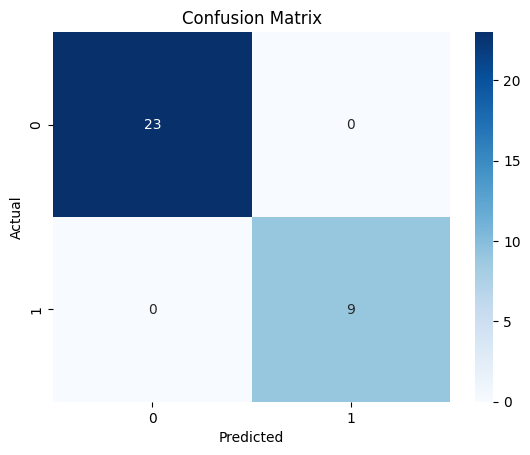

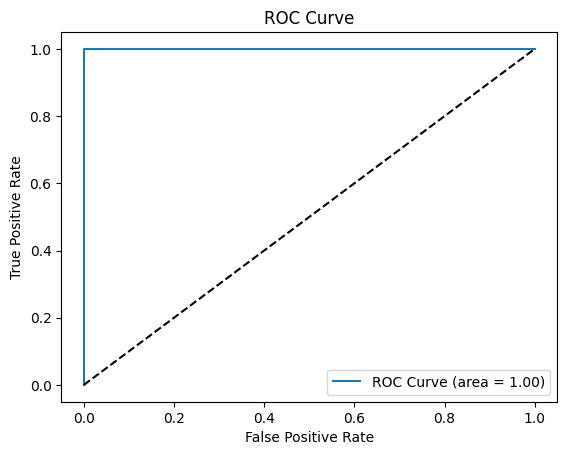

2026/05/18 10:52:21 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '84dbc946226d411fad693cb2f810821f', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/18 10:52:21 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers 


 Model evaluation completed.Thresholds: 
 [inf  1.  0.]


2026/05/18 10:52:21 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/18 10:52:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising cautio

GradientBoostingClassifier trained successfully.
Actual Values:[0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0]  and 
Predicted Values:[0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0]
Score: 1.00, 
Accuracy: 1.00, 
Recall_Score:1.00, 
Precision_Score:1.00, 
F1_Score:1.00, 
AUC_Score:1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00         9

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32
 



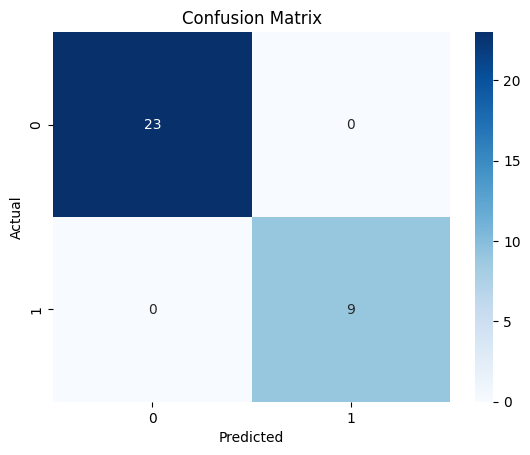

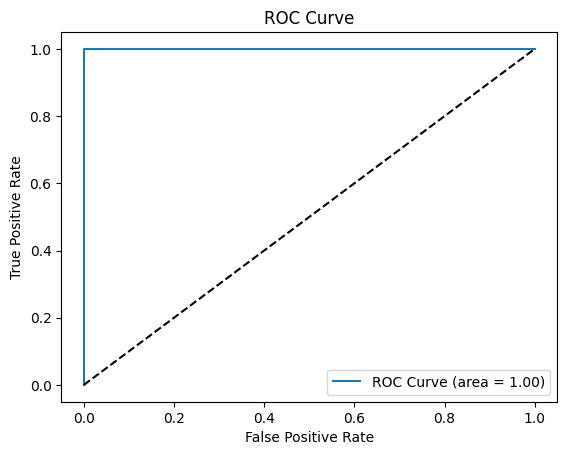

2026/05/18 10:52:32 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '711116327a9243c1814d099aadbda350', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/18 10:52:32 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers 


 Model evaluation completed.Thresholds: 
 [inf  1.  0.]


2026/05/18 10:52:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/18 10:52:43 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values.

DecisionTreeClassifier trained successfully.
Actual Values:[0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0]  and 
Predicted Values:[0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 1 0 1 0 1 0 1 0 0 1 0]
Score: 1.00, 
Accuracy: 1.00, 
Recall_Score:1.00, 
Precision_Score:1.00, 
F1_Score:1.00, 
AUC_Score:1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00         9

    accuracy                           1.00        32
   macro avg       1.00      1.00      1.00        32
weighted avg       1.00      1.00      1.00        32
 



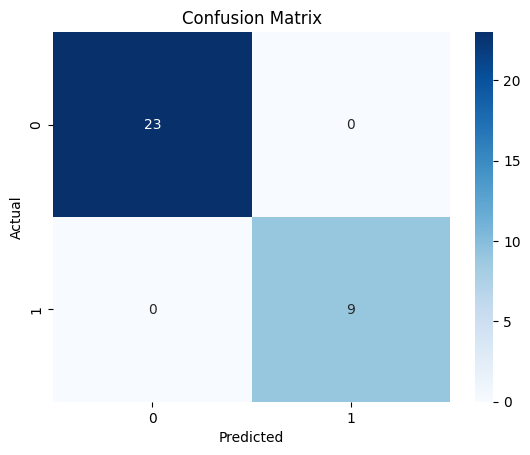

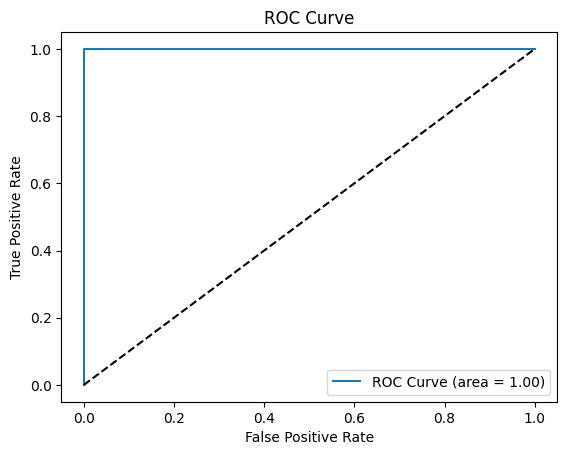

2026/05/18 10:52:44 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2c81c8cd657e47ee85e56decd2a148c1', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/18 10:52:44 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers 


 Model evaluation completed.Thresholds: 
 [inf  1.  0.]
Test Size: 0.25 
Training Set Shape: (118, 24)
Test Set Shape: (40, 24)
Training Labels Shape: (118,)
Test Labels Shape: (40,)


2026/05/18 10:52:44 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/18 10:52:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising cautio

RandomForestClassifier trained successfully.
Actual Values:[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1
 1 1 0]  and 
Predicted Values:[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1
 1 1 0]
Score: 1.00, 
Accuracy: 1.00, 
Recall_Score:1.00, 
Precision_Score:1.00, 
F1_Score:1.00, 
AUC_Score:1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40
 



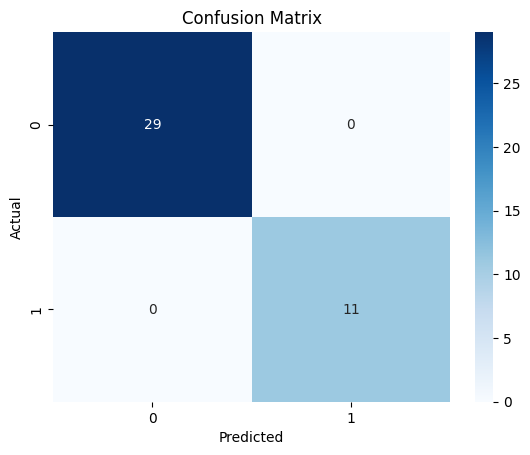

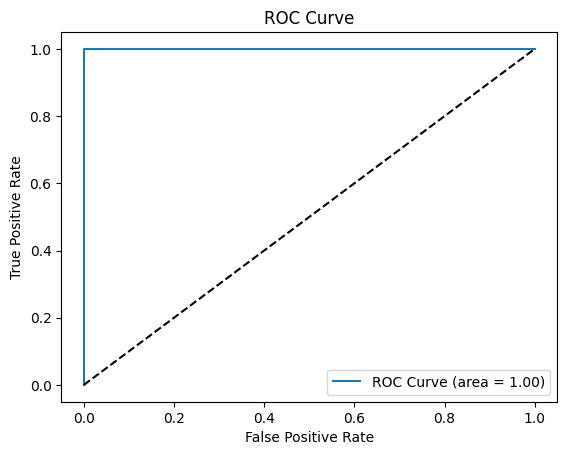

2026/05/18 10:52:56 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '09c3dce4801b4033be8cb23a623ecfaa', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/18 10:52:56 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers 


 Model evaluation completed.Thresholds: 
 [inf  1.  0.]


2026/05/18 10:52:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/18 10:53:06 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values.

GradientBoostingClassifier trained successfully.
Actual Values:[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1
 1 1 0]  and 
Predicted Values:[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1
 1 1 0]
Score: 1.00, 
Accuracy: 1.00, 
Recall_Score:1.00, 
Precision_Score:1.00, 
F1_Score:1.00, 
AUC_Score:1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40
 



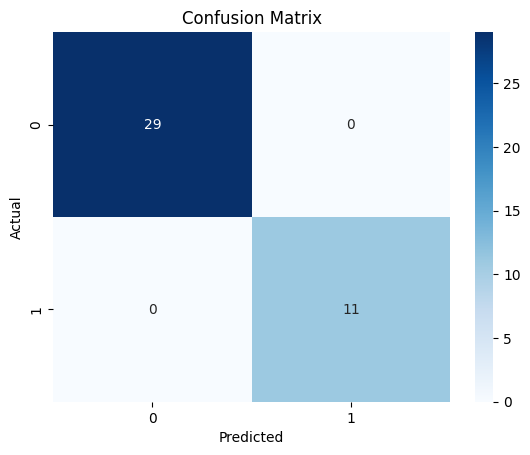

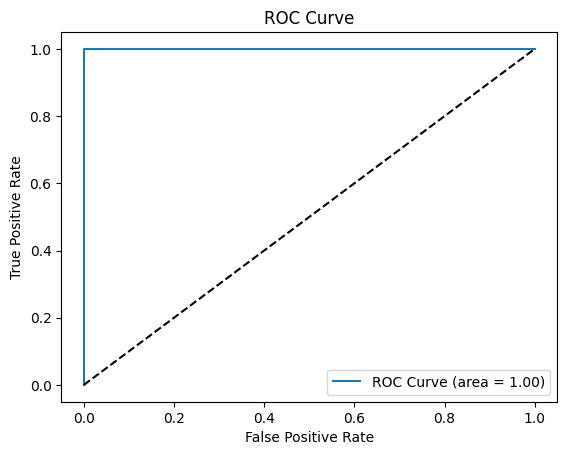

2026/05/18 10:53:07 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '4b775823c758413ab1bfb45b4de0006c', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/18 10:53:07 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers 


 Model evaluation completed.Thresholds: 
 [inf  1.  0.]


2026/05/18 10:53:18 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


DecisionTreeClassifier trained successfully.
Actual Values:[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1
 1 1 0]  and 
Predicted Values:[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1
 1 1 0]
Score: 1.00, 
Accuracy: 1.00, 
Recall_Score:1.00, 
Precision_Score:1.00, 
F1_Score:1.00, 
AUC_Score:1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        11

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40
 



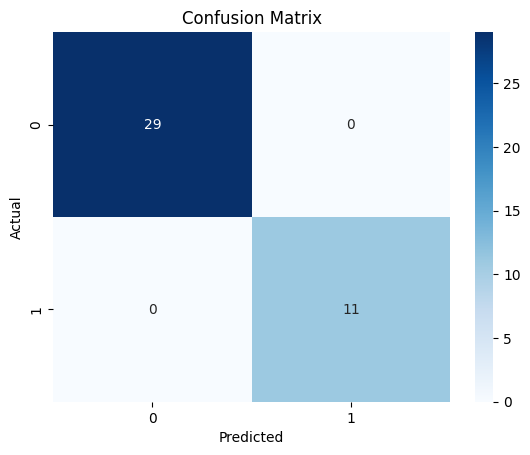

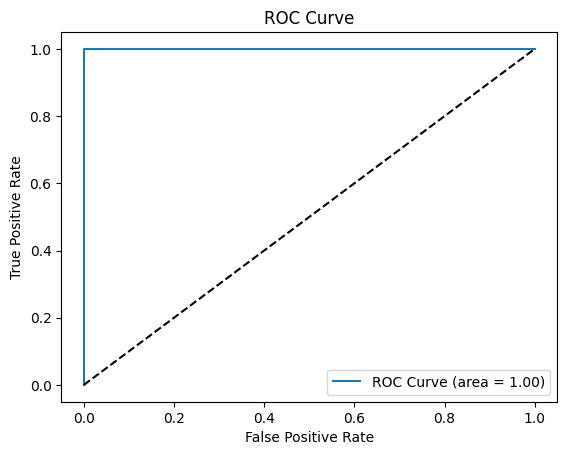

2026/05/18 10:53:19 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '2c0886885c0d4cb9acfdacfe22934908', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/18 10:53:19 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers 


 Model evaluation completed.Thresholds: 
 [inf  1.  0.]
Test Size: 0.3 
Training Set Shape: (110, 24)
Test Set Shape: (48, 24)
Training Labels Shape: (110,)
Test Labels Shape: (48,)


2026/05/18 10:53:19 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/18 10:53:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising cautio

RandomForestClassifier trained successfully.
Actual Values:[0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0
 0 0 0 0 1 1 0 0 1 1 0]  and 
Predicted Values:[0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0
 0 0 0 0 1 1 0 0 1 1 0]
Score: 1.00, 
Accuracy: 1.00, 
Recall_Score:1.00, 
Precision_Score:1.00, 
F1_Score:1.00, 
AUC_Score:1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        13

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48
 



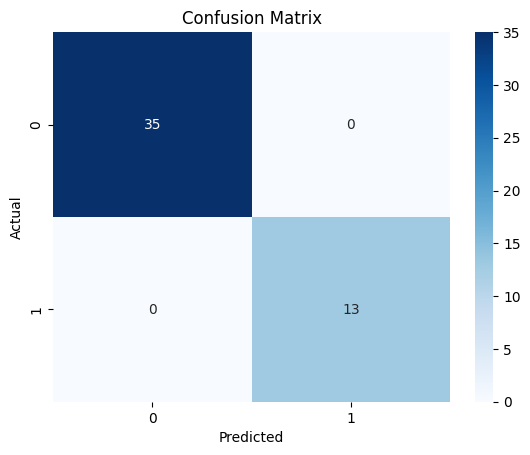

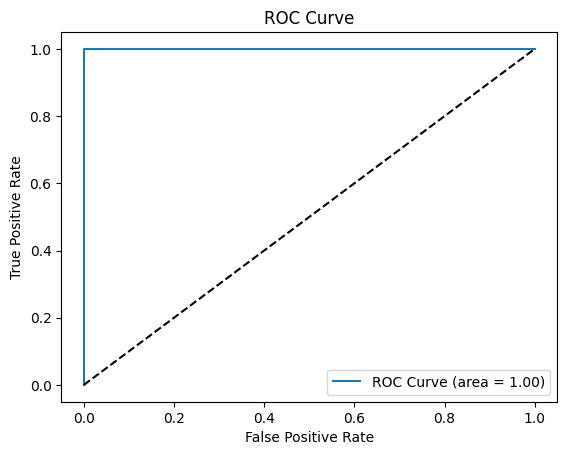

2026/05/18 10:53:31 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ddd4dfaabdad4786a21adbed46949fb6', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/18 10:53:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers 


 Model evaluation completed.Thresholds: 
 [inf  1.  0.]


2026/05/18 10:53:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/18 10:53:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising cautio

GradientBoostingClassifier trained successfully.
Actual Values:[0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0
 0 0 0 0 1 1 0 0 1 1 0]  and 
Predicted Values:[0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0
 0 0 0 0 1 1 0 0 0 1 0]
Score: 0.98, 
Accuracy: 0.98, 
Recall_Score:0.92, 
Precision_Score:1.00, 
F1_Score:0.96, 
AUC_Score:0.96
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        35
           1       1.00      0.92      0.96        13

    accuracy                           0.98        48
   macro avg       0.99      0.96      0.97        48
weighted avg       0.98      0.98      0.98        48
 



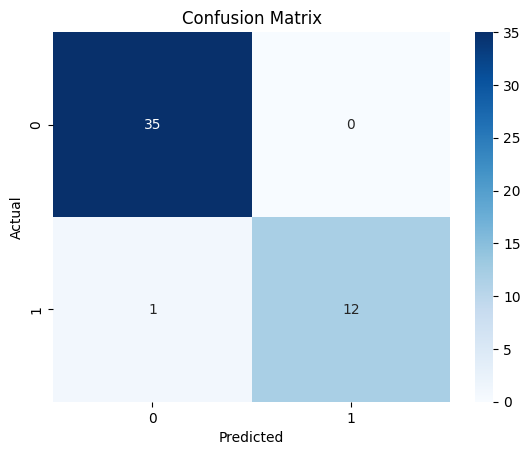

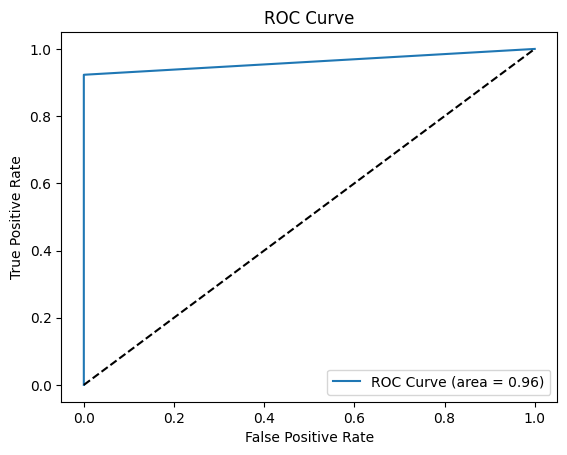

2026/05/18 10:53:43 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '339008446b084f1d87e43614212f9ba7', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/05/18 10:53:43 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers 


 Model evaluation completed.Thresholds: 
 [inf  1.  0.]


2026/05/18 10:53:53 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "C:\Users\RomeoNdlovu\AppData\Roaming\Python\Python312\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


DecisionTreeClassifier trained successfully.
Actual Values:[0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0
 0 0 0 0 1 1 0 0 1 1 0]  and 
Predicted Values:[0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0
 0 1 0 0 1 1 0 0 0 1 0]
Score: 0.92, 
Accuracy: 0.92, 
Recall_Score:0.92, 
Precision_Score:0.80, 
F1_Score:0.86, 
AUC_Score:0.92
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        35
           1       0.80      0.92      0.86        13

    accuracy                           0.92        48
   macro avg       0.88      0.92      0.90        48
weighted avg       0.92      0.92      0.92        48
 



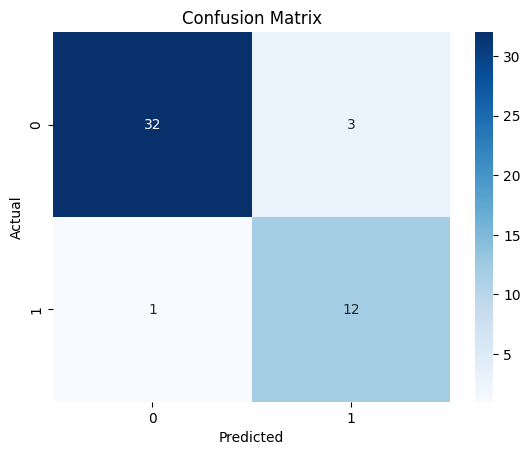

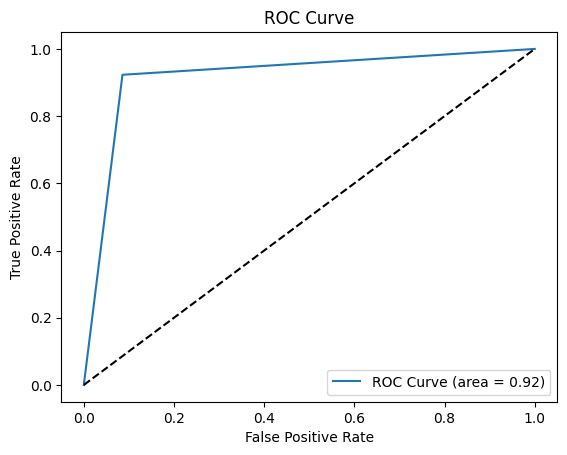


 Model evaluation completed.Thresholds: 
 [inf  1.  0.]


In [328]:
for size in test_size:
    X_train, X_test, y_train, y_test = split_data(X, y, size)
    print(f'Test Size: {size} \n{'='*20}')
    print(f'Training Set Shape: {X_train.shape}')
    print(f'Test Set Shape: {X_test.shape}')
    print(f'Training Labels Shape: {y_train.shape}')
    print(f'Test Labels Shape: {y_test.shape}')
    X_train_scaled, X_test_scaled = scale_features(X_train, X_test)
    #print_scaled_features(X_train_scaled, X_test_scaled)
    #model_training(Log_regress_model, X_train_scaled,X_test_scaled, y_train,y_test)
    #model_training(Distance_based_model, X_train_scaled,X_test_scaled, y_train,y_test)
    tree_model_training(Tree_based_models, X_train,X_test, y_train,y_test)